# Ejercicio 2 — Extracción de características Catch22


**¿Cómo podemos representar las siete series temporales del Laboratorio 1 mediante un conjunto común de características que permita compararlas posteriormente?**

Este notebook responde específicamente a los incisos **2.1–2.4**:

1. explicar la idea e importancia de catch22;
2. extraer exactamente 22 características para cada serie;
3. construir una matriz con una fila por serie y una columna por característica;
4. estandarizar las características antes de cualquier análisis comparativo.


## 1. Idea detrás de Catch22 — Inciso 2.1

Catch22 significa **22 CAnonical Time-series CHaracteristics**. Su propósito es transformar una serie temporal completa en un vector corto de 22 medidas que resume propiedades dinámicas como autocorrelación, predictibilidad, distribución de valores, cambios sucesivos, valores atípicos y escalamiento de las fluctuaciones.

Estas 22 características fueron seleccionadas de una biblioteca mucho mayor para obtener una representación informativa, poco redundante e interpretable, pero mucho más rápida de calcular. Gracias a esta representación, series con escalas y comportamientos diferentes pueden compararse dentro de un mismo espacio de características.

En este laboratorio se usa `catch24=False` para calcular **exactamente las 22 características solicitadas**. No se agregan la media y la desviación estándar opcionales de catch24.


## 2. Definición de las siete series

Se reutilizan las decisiones metodológicas del Laboratorio 1:

- **Total internacional:** turistas y excursionistas, excluyendo `País = Guatemala`.
- **Aérea:** turistas y excursionistas por vía aérea.
- **Terrestre:** turistas y excursionistas por vía terrestre.
- **Marítima:** todos los tipos de viajero por vía marítima, según la decisión tomada en L1.
- **América del Centro, América del Norte y Europa:** turistas y excursionistas clasificados mediante la columna `Región dos`.

Todas las series deben compartir un calendario mensual de enero de 2009 a junio de 2026.


In [1]:
from pathlib import Path
import sys
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


In [2]:
# Localizar automáticamente la raíz del repositorio.
ubicacion = Path.cwd().resolve()
ROOT = None

for carpeta in [ubicacion, *ubicacion.parents]:
    if (carpeta / "L02_DL_series" / "src" / "pipeline_catch22.py").exists():
        ROOT = carpeta
        break

if ROOT is None:
    raise FileNotFoundError(
        "No se encontró L02_DL_series/src/pipeline_catch22.py."
    )

SRC = ROOT / "L02_DL_series" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from pipeline_catch22 import (
    cargar_datos,
    construir_series,
    resumir_series,
    extraer_catch22,
    estandarizar_catch22,
    guardar_resultados,
)

print("Raíz del proyecto:", ROOT)
print("Python:", sys.version.split()[0])
print("pycatch22:", version("pycatch22"))


Raíz del proyecto: C:\Projects\Data-Science
Python: 3.10.11
pycatch22: 0.4.5


## 3. Carga, construcción y validación de las series

Antes de calcular catch22 se comprueba que las series tengan la misma longitud, fechas consecutivas, valores válidos y variación temporal. Esta validación evita obtener características indefinidas por filtros incorrectos o series constantes.


In [3]:
datos = cargar_datos()
series = construir_series(datos)
resumen_series = resumir_series(series)

print("Base original:", datos.shape)
print("Matriz de series:", series.shape)
print("Período:", series.index.min().date(), "a", series.index.max().date())

display(resumen_series.round(2))
display(series.head())


Base original: (161036, 14)
Matriz de series: (210, 7)
Período: 2009-01-01 a 2026-06-01


,observaciones,valores_faltantes,valores_unicos,ceros,minimo,maximo,media,desviacion
total_internacional,210,0,206,5,0.0,365573.02,156388.20,74176.33
aerea,210,0,210,0,489.0,158463.00,90568.66,27855.30
terrestre,210,0,210,0,5240.0,291272.07,131391.68,60815.99
maritima,210,0,179,27,0.0,29506.00,5851.34,6708.80
america_centro,210,0,210,0,9779.0,359173.00,158494.91,66477.13
america_norte,210,0,206,5,0.0,98379.81,43622.91,17881.10
europa,210,0,206,5,0.0,22824.35,10234.62,4401.30


,total_internacional,aerea,terrestre,maritima,america_centro,america_norte,europa
Fecha,,,,,,,
2009-01-01,93983.588581,81693.0,67442.029345,13379.0,93848.087646,36033.941699,12061.0
2009-02-01,87406.515953,70099.0,56266.692203,11674.0,73988.387264,33970.304940,12642.0
2009-03-01,111155.348594,84494.0,73111.673819,11522.0,96398.150900,41482.522919,13676.0
2009-04-01,115076.159015,80618.0,89897.467694,9290.0,114286.682101,39595.785593,10562.0
2009-05-01,80712.279455,64621.0,58898.524351,6517.0,83304.469915,29239.054436,6245.0


In [4]:
# Pruebas estructurales antes de Catch22.
calendario_esperado = pd.date_range(
    "2009-01-01",
    "2026-06-01",
    freq="MS",
)

assert series.shape == (210, 7)
assert series.index.equals(calendario_esperado)
assert not series.index.has_duplicates
assert series.isna().sum().sum() == 0
assert np.isfinite(series.to_numpy(dtype=float)).all()
assert (series >= 0).all().all()
assert (series.nunique() > 1).all()

print("Validación de las siete series: CORRECTA")


Validación de las siete series: CORRECTA


### Visualización descriptiva de las series

La siguiente gráfica estandariza cada serie únicamente para visualizar y comparar su forma temporal. Esta transformación visual **no sustituye** la estandarización posterior de la matriz catch22.


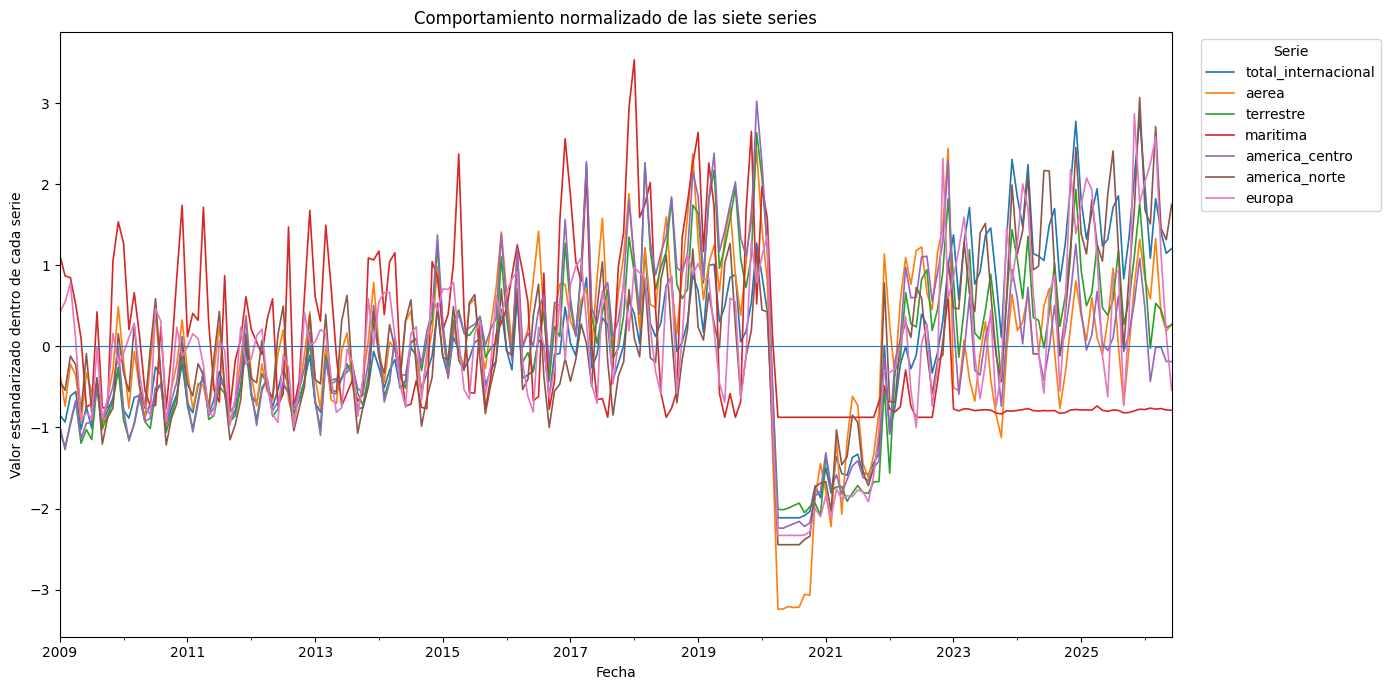

In [5]:
series_visual = (series - series.mean()) / series.std(ddof=0)

ax = series_visual.plot(
    figsize=(14, 7),
    linewidth=1.2,
)

ax.set_title("Comportamiento normalizado de las siete series")
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor estandarizado dentro de cada serie")
ax.axhline(0, linewidth=0.8)
ax.legend(
    title="Serie",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


## 4. Extracción de las 22 características — Incisos 2.2 y 2.3

Se ejecuta catch22 una vez por serie. El resultado se organiza en una matriz donde cada fila representa una serie temporal y cada columna una característica.


In [6]:
matriz_catch22 = extraer_catch22(series)

print("Dimensión de la matriz Catch22:", matriz_catch22.shape)
display(matriz_catch22)


Dimensión de la matriz Catch22: (7, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,
total_internacional,-0.629801,-0.383379,14.222404,2,0.529440,-0.027341,0.923445,43.0,0.020833,3,...,0.038462,0.800000,0.328571,0.878634,5.0,1.823124,0.857143,0.738095,0.073631,0.493498
aerea,-0.398224,-0.114663,6.590944,10,0.206212,-0.162779,0.956938,34.0,0.010204,11,...,0.071429,0.185714,0.323810,0.758284,5.0,2.000891,0.857143,0.857143,0.171806,0.738677
terrestre,0.277301,-0.193022,9.572755,2,0.484160,-0.024702,0.933014,29.0,0.013774,3,...,0.055556,0.219048,0.328571,0.817693,6.0,1.781787,0.833333,0.857143,0.098175,0.615634
maritima,-0.432379,-0.652284,2.770974,6,0.122952,-0.082278,0.669856,9.0,0.008328,11,...,0.200000,0.033333,0.423810,0.746837,5.0,1.843130,0.857143,0.857143,0.515418,0.869047
america_centro,0.390827,0.128035,8.865918,3,0.400353,-0.064562,0.918660,42.0,0.013774,7,...,0.055556,0.171429,0.323810,0.815207,6.0,1.833461,0.785714,0.857143,0.122718,0.634561
america_norte,0.311334,-0.238855,9.076667,2,0.271266,-0.011904,0.942584,12.0,0.036458,3,...,0.038462,0.828571,0.323810,0.740469,5.0,2.053424,0.166667,0.738095,0.098175,0.722270
europa,0.267546,0.008255,4.448073,2,0.348034,0.084226,0.942584,8.0,0.013889,8,...,0.058824,0.819048,0.333333,0.762117,6.0,2.055070,0.142857,0.738095,0.171806,0.782764


In [7]:
# Pruebas de la matriz sin escalar.
assert matriz_catch22.shape == (7, 22)
assert matriz_catch22.index.tolist() == series.columns.tolist()
assert matriz_catch22.columns.nunique() == 22
assert matriz_catch22.isna().sum().sum() == 0
assert np.isfinite(matriz_catch22.to_numpy(dtype=float)).all()

print("Validación de la matriz Catch22: CORRECTA")


Validación de la matriz Catch22: CORRECTA


## 5. Estandarización de características — Inciso 2.4

Las 22 características tienen rangos diferentes. Por ello se aplica `StandardScaler` a la matriz completa, columna por columna. La estandarización se realiza **después** de extraer catch22 y antes de cualquier PCA, clustering o análisis de distancias.


In [8]:
matriz_catch22_scaled, escalador = estandarizar_catch22(
    matriz_catch22
)

display(matriz_catch22_scaled)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,
total_internacional,-1.489124,-0.741822,1.804027,-0.651631,1.408185,0.200586,0.269164,1.242238,0.462689,-1.058334,...,-0.677254,1.091621,-0.359712,1.926118,-0.866025,-0.819668,0.692015,-1.154701,-0.742156,-1.754744
aerea,-0.913725,0.385538,-0.385782,2.155395,-0.963061,-1.740805,0.625624,0.611101,-0.742202,1.312335,...,-0.049726,-0.754322,-0.499600,-0.644647,-0.866025,0.801858,0.692015,0.866025,-0.049477,0.393369
terrestre,0.764759,0.056790,0.469834,-0.651631,1.076004,0.238406,0.371010,0.260469,-0.337518,-1.058334,...,-0.351869,-0.654155,-0.359712,0.624375,1.154701,-1.196730,0.615125,0.866025,-0.568986,-0.684653
maritima,-0.998588,-1.869973,-1.481904,0.751882,-1.573865,-0.586890,-2.429750,-1.142058,-0.954825,1.312335,...,2.397635,-1.212230,2.438050,-0.889150,-0.866025,-0.637182,0.692015,0.866025,2.374899,1.535597
america_centro,1.046838,1.403738,0.267010,-0.300753,0.461185,-0.332953,0.218241,1.172112,-0.337518,0.127000,...,-0.351869,-0.797251,-0.499600,0.571263,1.154701,-0.725377,0.461344,0.866025,-0.395817,-0.518828
america_norte,0.849320,-0.135492,0.327484,-0.651631,-0.485818,0.421863,0.472855,-0.931679,2.233880,-1.058334,...,-0.677254,1.177478,-0.499600,-1.025191,-0.866025,1.281044,-1.537812,-1.154701,-0.568986,0.249625
europa,0.740520,0.901221,-1.000668,-0.651631,0.077369,1.799794,0.472855,-1.212184,-0.324506,0.423334,...,-0.289663,1.148859,-0.219824,-0.562768,1.154701,1.296055,-1.614702,-1.154701,-0.049477,0.779635


In [9]:
# Pruebas de la matriz estandarizada.
assert matriz_catch22_scaled.shape == (7, 22)
assert matriz_catch22_scaled.index.equals(matriz_catch22.index)
assert matriz_catch22_scaled.columns.equals(matriz_catch22.columns)
assert np.isfinite(matriz_catch22_scaled.to_numpy(dtype=float)).all()

medias = matriz_catch22_scaled.mean(axis=0)
desviaciones = matriz_catch22_scaled.std(axis=0, ddof=0)

assert np.allclose(medias, 0.0, atol=1e-10)

columnas_variables = matriz_catch22.columns[
    matriz_catch22.nunique() > 1
]
assert np.allclose(
    desviaciones[columnas_variables],
    1.0,
    atol=1e-10,
)

print("Validación de la estandarización: CORRECTA")


Validación de la estandarización: CORRECTA


### Vista preliminar de los perfiles Catch22

El mapa de calor permite verificar visualmente que las siete series presentan perfiles diferentes. La interpretación formal de grupos, distancias y componentes principales corresponde al notebook posterior de agrupamiento.


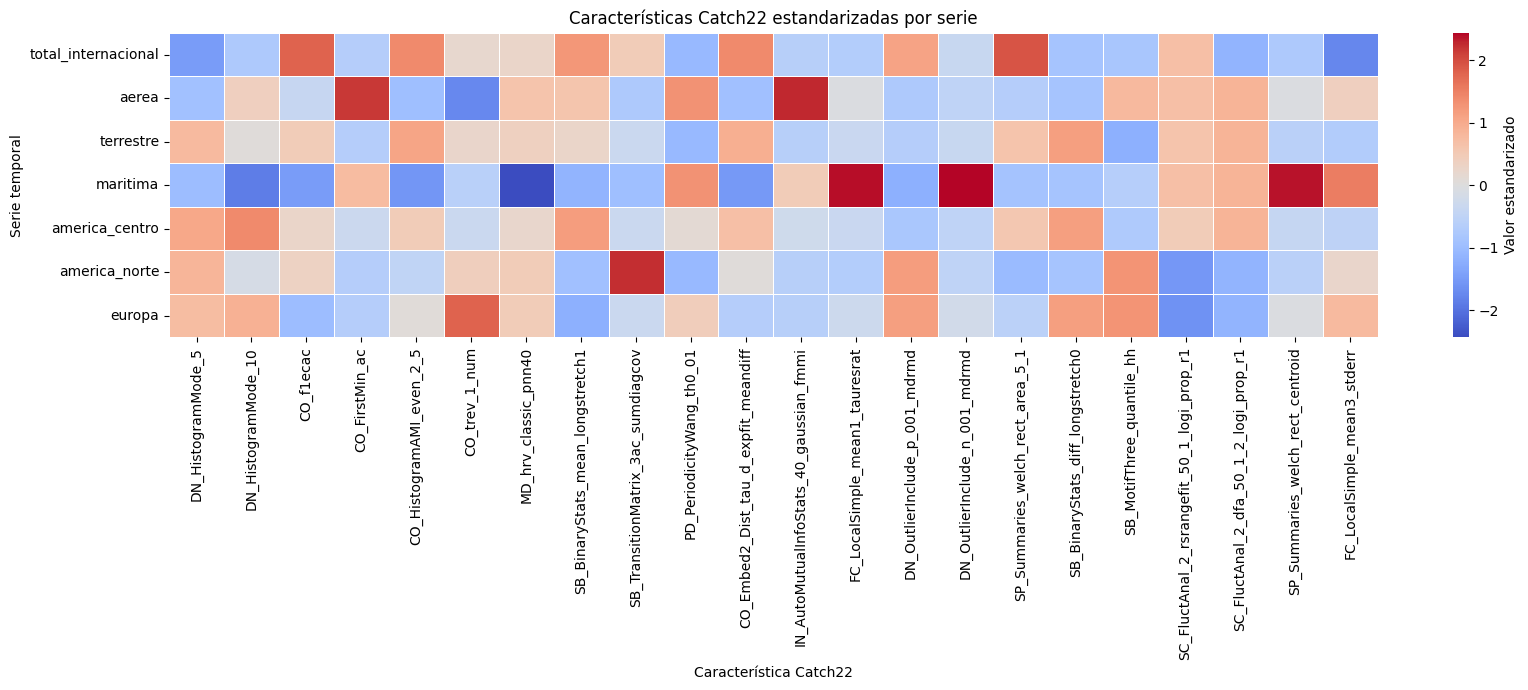

In [10]:
plt.figure(figsize=(17, 7))

sns.heatmap(
    matriz_catch22_scaled,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Valor estandarizado"},
)

plt.title("Características Catch22 estandarizadas por serie")
plt.xlabel("Característica Catch22")
plt.ylabel("Serie temporal")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Guardado y comprobación de los CSV

Se guardan tres archivos:

1. `series_mensuales.csv`: calendario común y las siete series;
2. `catch22_features.csv`: matriz original de 7 × 22;
3. `catch22_features_scaled.csv`: matriz estandarizada de 7 × 22.

No es necesario crear un CSV por serie. Mantener las siete columnas juntas garantiza que todas compartan las mismas fechas y simplifica las validaciones.


In [11]:
rutas = guardar_resultados(
    series,
    matriz_catch22,
    matriz_catch22_scaled,
)

for nombre, ruta in rutas.items():
    print(f"{nombre}: {ruta}")


series: C:\Projects\Data-Science\L02_DL_series\data\series_mensuales.csv
catch22: C:\Projects\Data-Science\L02_DL_series\data\catch22_features.csv
catch22_scaled: C:\Projects\Data-Science\L02_DL_series\data\catch22_features_scaled.csv


In [12]:
# Prueba de lectura: confirma que los archivos guardados mantienen
# dimensiones, índices, nombres y valores.

series_csv = pd.read_csv(
    rutas["series"],
    index_col="Fecha",
    parse_dates=True,
)

catch22_csv = pd.read_csv(
    rutas["catch22"],
    index_col="serie",
)

catch22_scaled_csv = pd.read_csv(
    rutas["catch22_scaled"],
    index_col="serie",
)

assert series_csv.shape == (210, 7)
assert catch22_csv.shape == (7, 22)
assert catch22_scaled_csv.shape == (7, 22)

assert series_csv.index.equals(series.index)
assert catch22_csv.index.tolist() == matriz_catch22.index.tolist()
assert catch22_scaled_csv.columns.tolist() == matriz_catch22_scaled.columns.tolist()

assert np.allclose(series_csv, series, rtol=1e-12, atol=1e-9)
assert np.allclose(catch22_csv, matriz_catch22, rtol=1e-11, atol=1e-9)
assert np.allclose(
    catch22_scaled_csv,
    matriz_catch22_scaled,
    rtol=1e-11,
    atol=1e-9,
)

print("Lectura y consistencia de los tres CSV: CORRECTA")


Lectura y consistencia de los tres CSV: CORRECTA


## 7. Resultado

Se construyeron siete series mensuales con 210 observaciones cada una. Para cada serie se calcularon exactamente 22 características catch22, produciendo una matriz de **7 filas × 22 columnas**.

La matriz fue estandarizada una sola vez, por característica, utilizando las siete series. Los tres CSV quedaron listos para el análisis posterior de PCA, clustering, correlaciones y distancias.

## Referencias

- Lubba, C. H. et al. (2019). *catch22: CAnonical Time-series CHaracteristics*. Data Mining and Knowledge Discovery, 33, 1821–1852. https://doi.org/10.1007/s10618-019-00647-x
- pycatch22: https://pypi.org/project/pycatch22/
